# Global metrics and invariant measures over long forecast horizons

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys

parrot_color = np.array([46, 69, 81]) / 255
dynamix_color = np.array([152, 199, 71]) / 255
simplex_color = np.array([234, 57, 89]) / 255
chronos_color = np.array([80, 155, 143]) / 255

from scipy.stats import spearmanr, pearsonr

def corr_se(r, n):
    """
    Args:
        r (float): Pearson correlation coefficient.
        n (int): Sample size.

    Returns:
        float: Approximate standard error of r.
    """
    return (1 - r**2) / np.sqrt(n - 3)


plt.rcParams["font.family"] = "Helvetica"

First, we check that the internal Lyapunov estimator is behaving as expected. We calculate a purely data-driven estimate of the Lyapunov exponent, and compare it to a value that was estimated using the Jacobian of the true underlying dynamical system.

In [ ]:
from dysts.systems import get_attractor_list
import dysts.flows as dfl
from scipy.stats import spearmanr, pearsonr

from dysts.analysis import max_lyapunov_exponent_rosenstein, max_lyapunov_exponent_rosenstein_multivariate

eq_names = get_attractor_list()
all_lyap_true = list()
all_lyap1 = list()
all_lyap2 = list()
for eq_name in eq_names:
    print(eq_name, flush=True)
    eq = getattr(dfl, eq_name)()
    all_lyap_true.append(eq.maximum_lyapunov_estimated)

    tpts, sol = eq.make_trajectory(1000, standardize=True, return_times=True)
    dt = tpts[1] - tpts[0]
    all_lyap1.append(max_lyapunov_exponent_rosenstein(sol) / dt)
    all_lyap2.append(max_lyapunov_exponent_rosenstein_multivariate(sol) / dt)

    if len(all_lyap_true) > 3:
        print(pearsonr(all_lyap_true, all_lyap1)[0], flush=True)
        print(pearsonr(all_lyap_true, all_lyap2)[0], flush=True)




## Long term metrics

Check that the Lyapunov exponents of long forecasts are close to the true Lyapunov exponents.

In [6]:
import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')

import torch
from src.model.forecaster import DynaMixForecaster
from src.utilities.utilities import load_hf_model

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster



import sys
sys.path.append('./..')
from models.parrot import context_parroting_forecast

/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: divide by zero encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: overflow encountered in matmul
  K = R.T @ R / M + np.eye(M)
/Users/william/program_repos/parroting/benchmark/DynaMix/src/model/dynamix.py:95: RuntimeWarning: invalid value encountered in matmul
  K = R.T @ R / M + np.eye(M)


In [ ]:
from dysts.systems import get_attractor_list
import dysts.flows as dfl
from scipy.stats import spearmanr, pearsonr

from dysts.analysis import max_lyapunov_exponent_rosenstein_multivariate, gp_dim
from dysts.metrics import average_hellinger_distance, estimate_kl_divergence

CONTEXT_LENGTH = 2000
FORECAST_LENGTH = 10000

eq_names = get_attractor_list()
# all_lyap_true, all_lyap_parrot, all_lyap_dynamix = list(), list(), list()
all_lyap_true, all_lyap_parrot, all_lyap_dynamix = dict(), dict(), dict()
all_cdim_true, all_cdim_parrot, all_cdim_dynamix = dict(), dict(), dict()
all_hellinger_dynamix, all_hellinger_parrot = list(), list()
all_kl_dynamix, all_kl_parrot = list(), list()
for eq_name in eq_names:

    ## Integration of this system is unstable at our chosen timestep
    if eq_name == "SprottG":
        continue

    print(eq_name, flush=True)
    eq = getattr(dfl, eq_name)()

    try:
        ## Make a long trajectory and split it into context and true trajectory
        np.random.seed(0)
        eq.ic += np.random.randn(len(eq.ic)) * 0.3
        traj = eq.make_trajectory(500 + CONTEXT_LENGTH + FORECAST_LENGTH, standardize=True)[500:]
        traj_context = traj[:CONTEXT_LENGTH, :]
        traj_true = traj[CONTEXT_LENGTH:, :]

        ## Generate predictions using context parroting
        traj_pred = list()
        for mode in range(traj_context.shape[1]):
            traj_pred_mode = context_parroting_forecast(
                traj_context[:, mode], forecast_total_length=FORECAST_LENGTH
            )[2]
            traj_pred.append(traj_pred_mode.copy())
        traj_pred_parrot = np.array(traj_pred).T

        ## Generate predictions using DynaMix
        context_traj_tensor  = torch.tensor(traj_context)
        with torch.no_grad(): 
            reconstruction = forecaster.forecast(
                context=context_traj_tensor,
                horizon=FORECAST_LENGTH, # Match the horizon of the ground truth
                standardize=False,
            )
        traj_pred_dynamix = reconstruction.detach().numpy()

        ## Compute the Lyapunov exponents
        all_lyap_true[eq_name] = max_lyapunov_exponent_rosenstein_multivariate(traj_true)
        all_lyap_dynamix[eq_name] = max_lyapunov_exponent_rosenstein_multivariate(traj_pred_dynamix)
        all_lyap_parrot[eq_name] = max_lyapunov_exponent_rosenstein_multivariate(traj_pred_parrot)

        ## Compute the GP dimension
        all_cdim_true[eq_name] = gp_dim(traj_true)
        all_cdim_dynamix[eq_name] = gp_dim(traj_pred_dynamix)
        all_cdim_parrot[eq_name] = gp_dim(traj_pred_parrot)

        # ## Compute the Hellinger distance and KL divergence
        all_hellinger_dynamix.append(average_hellinger_distance(traj_true, traj_pred_dynamix)) 
        all_hellinger_parrot.append(average_hellinger_distance(traj_true, traj_pred_parrot)) 

        all_kl_dynamix.append([
            estimate_kl_divergence(traj_true, traj_pred_dynamix, sigma_scale=0.01),
            estimate_kl_divergence(traj_true, traj_pred_dynamix, sigma_scale=0.1),
            estimate_kl_divergence(traj_true, traj_pred_dynamix, sigma_scale=1.0),
            estimate_kl_divergence(traj_true, traj_pred_dynamix, sigma_scale=10.0),
        ])
        all_kl_parrot.append([
            estimate_kl_divergence(traj_true, traj_pred_parrot, sigma_scale=0.01),
            estimate_kl_divergence(traj_true, traj_pred_parrot, sigma_scale=0.1),
            estimate_kl_divergence(traj_true, traj_pred_parrot, sigma_scale=1.0),
            estimate_kl_divergence(traj_true, traj_pred_parrot, sigma_scale=10.0),
        ])
    except Exception as e:
        print(f"Exception {e} for {eq_name}")
    
    np.array(all_kl_dynamix).dump('all_kl_dynamix_sweep.pkl')
    np.array(all_kl_parrot).dump('all_kl_parrot_sweep.pkl')


all_hellinger_dynamix = np.array(all_hellinger_dynamix)
all_hellinger_parrot = np.array(all_hellinger_parrot)
all_kl_dynamix = np.array(all_kl_dynamix)
all_kl_parrot = np.array(all_kl_parrot)


np.array(all_hellinger_dynamix).dump('all_hellinger_dynamix2.pkl')
np.array(all_hellinger_parrot).dump('all_hellinger_parrot2.pkl')
np.array(all_kl_dynamix).dump('all_kl_dynamix_sweep.pkl')
np.array(all_kl_parrot).dump('all_kl_parrot_sweep.pkl')

# Save the results
import pandas as pd
df_all = pd.concat([
    pd.DataFrame.from_dict(all_lyap_true, orient='index'),
    pd.DataFrame.from_dict(all_lyap_dynamix, orient='index'),
    pd.DataFrame.from_dict(all_lyap_parrot, orient='index')
], axis=1, join='inner', ignore_index=True)
## name columns
df_all.columns = ['true', 'dynamix', 'parrot']
## drop columnns with infinite values
df_all = df_all.replace([np.inf, -np.inf], np.nan).dropna()
df_all.to_csv('all_lyap_true_dynamix_parrot2.csv')


# Save the results
import pandas as pd
df_all_cdim = pd.concat([
    pd.DataFrame.from_dict(all_cdim_true, orient='index'),
    pd.DataFrame.from_dict(all_cdim_dynamix, orient='index'),
    pd.DataFrame.from_dict(all_cdim_parrot, orient='index')
], axis=1, join='inner', ignore_index=True)
## name columns
df_all_cdim.columns = ['true', 'dynamix', 'parrot']
# ## drop columnns with infinite values
df_all_cdim = df_all_cdim.replace([np.inf, -np.inf], np.nan).dropna()
df_all_cdim.to_csv('all_cdim_true_dynamix_parrot2.csv')


    

Aizawa


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


AnishchenkoAstakhov
Arneodo
ArnoldBeltramiChildress
ArnoldWeb
AtmosphericRegime
BeerRNN


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


BelousovZhabotinsky


...

/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


YuWang2


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


ZhouChen


/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: divide by zero encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: overflow encountered in matmul
  return x @ self._LP
/Users/william/program_repos/parroting/.venv/lib/python3.13/site-packages/scipy/stats/_covariance.py:633: RuntimeWarning: invalid value encountered in matmul
  return x @ self._LP


In [ ]:
all_kl_dynamix = np.load('all_kl_dynamix_sweep.pkl', allow_pickle=True)
all_kl_parrot = np.load('all_kl_parrot_sweep.pkl', allow_pickle=True)

# print(f"{np.mean(all_kl_dynamix):.3f} ± {np.std(all_kl_dynamix):.3f}")
# print(f"{np.mean(all_kl_parrot):.3f} ± {np.std(all_kl_parrot):.3f}")

In [3]:
import pandas as pd
df_all_cdim = pd.read_csv('../analysis/all_cdim_true_dynamix_parrot.csv')
corr_dynamix = pearsonr(df_all_cdim["true"], df_all_cdim["dynamix"])[0]
corr_parrot = pearsonr(df_all_cdim["true"], df_all_cdim["parrot"])[0]
se_dynamix = corr_se(corr_dynamix, len(df_all_cdim))
se_parrot = corr_se(corr_parrot, len(df_all_cdim))
print(f"{corr_dynamix:.3f} ± {se_dynamix:.3f}")
print(f"{corr_parrot:.3f} ± {se_parrot:.3f}")


0.441 ± 0.073
0.832 ± 0.028


In [4]:
import pandas as pd
df_all_cdim = pd.read_csv('../analysis/all_cdim_true_dynamix_parrot.csv')
corr_dynamix = pearsonr(df_all_cdim["true"], df_all_cdim["dynamix"])[0]
corr_parrot = pearsonr(df_all_cdim["true"], df_all_cdim["parrot"])[0]
se_dynamix = corr_se(corr_dynamix, len(df_all_cdim))
se_parrot = corr_se(corr_parrot, len(df_all_cdim))
print(f"{corr_dynamix:.3f} ± {se_dynamix:.3f}")
print(f"{corr_parrot:.3f} ± {se_parrot:.3f}")


0.441 ± 0.073
0.832 ± 0.028


In [5]:
import pandas as pd
df_all = pd.read_csv('../analysis/all_lyap_true_dynamix_parrot.csv')
corr_dynamix = pearsonr(df_all["true"], df_all["dynamix"])[0]
corr_parrot = pearsonr(df_all["true"], df_all["parrot"])[0]
se_dynamix = corr_se(corr_dynamix, len(df_all))
se_parrot = corr_se(corr_parrot, len(df_all))
print(f"{corr_dynamix:.3f} ± {se_dynamix:.3f}")
print(f"{corr_parrot:.3f} ± {se_parrot:.3f}")


0.278 ± 0.100
0.328 ± 0.097


In [ ]:
all_hellinger_dynamix = np.load('../analysis/all_hellinger_dynamix.pkl', allow_pickle=True)
all_hellinger_parrot = np.load('../analysis/all_hellinger_parrot.pkl', allow_pickle=True)

print(f"{np.mean(all_hellinger_dynamix):.3f} ± {np.std(all_hellinger_dynamix):.3f}")
print(f"{np.mean(all_hellinger_parrot):.3f} ± {np.std(all_hellinger_parrot):.3f}")

0.595 ± 0.166
0.591 ± 0.198


In [9]:

all_kl_dynamix = np.load('./all_kl_dynamix_sweep.pkl', allow_pickle=True)
all_kl_parrot = np.load('./all_kl_parrot_sweep.pkl', allow_pickle=True)

print("Width 0.01")
print(f"{np.nanmean(all_kl_dynamix[:, 0]):.3f} ± {np.nanstd(all_kl_dynamix[:, 0]) / np.sqrt(all_kl_dynamix.shape[0]):.3f}")
print(f"{np.nanmean(all_kl_parrot[:, 0]):.3f} ± {np.nanstd(all_kl_parrot[:, 0]) / np.sqrt(all_kl_parrot.shape[0]):.3f}")

print("\nWidth 0.1")
print(f"{np.nanmean(all_kl_dynamix[:, 1]):.3f} ± {np.nanstd(all_kl_dynamix[:, 1]) / np.sqrt(all_kl_dynamix.shape[0]):.3f}")
print(f"{np.nanmean(all_kl_parrot[:, 1]):.3f} ± {np.nanstd(all_kl_parrot[:, 1]) / np.sqrt(all_kl_parrot.shape[0]):.3f}")

print("\nWidth 1.0")
print(f"{np.nanmean(all_kl_dynamix[:, 2]):.3f} ± {np.nanstd(all_kl_dynamix[:, 2]) / np.sqrt(all_kl_dynamix.shape[0]):.3f}")
print(f"{np.nanmean(all_kl_parrot[:, 2]):.3f} ± {np.nanstd(all_kl_parrot[:, 2]) / np.sqrt(all_kl_parrot.shape[0]):.3f}")

print("\nWidth 10.0")
print(f"{np.nanmean(all_kl_dynamix[:, 3]):.3f} ± {np.nanstd(all_kl_dynamix[:, 3]) / np.sqrt(all_kl_dynamix.shape[0]):.3f}")
print(f"{np.nanmean(all_kl_parrot[:, 3]):.3f} ± {np.nanstd(all_kl_parrot[:, 3]) / np.sqrt(all_kl_parrot.shape[0]):.3f}")



Width 0.01
6.921 ± 0.594
4.194 ± 0.474

Width 0.1
2.786 ± 0.361
1.589 ± 0.281

Width 1.0
0.624 ± 0.128
0.469 ± 0.162

Width 10.0
-0.098 ± 0.076
-0.075 ± 0.078


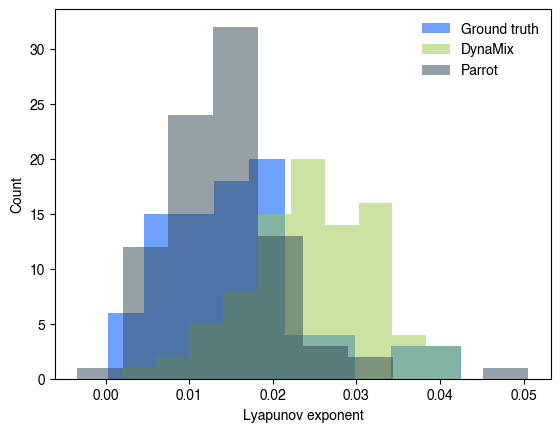

In [ ]:
import pandas as pd
df_all = pd.read_csv('../analysis/all_lyap_true_dynamix_parrot.csv')

plt.hist(df_all["true"], color=(0.372549, 0.596078, 1), alpha=0.9, label="Ground truth")
plt.hist(df_all["dynamix"], color=dynamix_color, alpha=0.5, label="DynaMix")
plt.hist(df_all["parrot"], color=parrot_color, alpha=0.5, label="Parrot")
plt.xlabel("Lyapunov exponent")
plt.ylabel("Count")
plt.legend(frameon=False)

# dg.better_savefig("../analysis/lyapunov_histogram.pdf", dpi=300, transparent=True)